<a href="https://colab.research.google.com/github/Ashishsahu26/Customer-Complaint-Resolution-Time-Prediction/blob/main/banking_issues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
path = "/content/drive/MyDrive/Projects_dataset/consumer_complaints_response.csv"
df = pd.read_csv(path)

/tmp/ipython-input-2444613221.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [ ]:
df.head()

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
0,8/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,9/3/2013,Closed with explanation,Yes,Yes,511074.0
1,8/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,9/3/2013,Closed with explanation,Yes,Yes,511080.0
2,8/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,9/18/2013,Closed with explanation,Yes,No,510473.0
3,8/30/2013,Student loan,Non-federal student loan,Repaying your loan,Repaying your loan,NaN,NaN,"Navient Solutions, Inc.",MD,21402,NaN,NaN,Email,8/30/2013,Closed with explanation,Yes,Yes,510326.0
4,8/30/2013,Debt collection,Credit card,False statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,GA,30106,NaN,NaN,Web,8/30/2013,Closed with explanation,Yes,Yes,511067.0


In [ ]:
df.tail()

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
555952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
555953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
555954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
555955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
555956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape[0]

555957

In [ ]:
df = df.dropna(how='all')


In [ ]:
df.shape[0]

199999

In [ ]:
columns = df.columns
print(len(columns))

18


In [ ]:
print(df.columns)

Index(['date_received', 'product', 'sub_product', 'issue', 'sub_issue',
       'consumer_complaint_narrative', 'company_public_response', 'company',
       'state', 'zipcode', 'tags', 'consumer_consent_provided',
       'submitted_via', 'date_sent_to_company', 'company_response_to_consumer',
       'timely_response', 'consumer_disputed?', 'complaint_id'],
      dtype='object')


In [ ]:
import numpy as np
arr = np.array(columns)

In [ ]:
print(arr)

['date_received' 'product' 'sub_product' 'issue' 'sub_issue'
 'consumer_complaint_narrative' 'company_public_response' 'company'
 'state' 'zipcode' 'tags' 'consumer_consent_provided' 'submitted_via'
 'date_sent_to_company' 'company_response_to_consumer' 'timely_response'
 'consumer_disputed?' 'complaint_id']


In [ ]:
print(df['consumer_complaint_narrative'][10:25])

10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
20    NaN
21    NaN
22    NaN
23    NaN
24    NaN
Name: consumer_complaint_narrative, dtype: object


In [ ]:
print(df['consumer_complaint_narrative'].isnull().sum())

199449


In [ ]:
print(df['consumer_complaint_narrative'].value_counts())


consumer_complaint_narrative
This company continues to report on my credit report after I sent them a letter telling them that this account was not mine and I have no idea what it is or who it belongs to! \n\nI asked for proof of a signed contract, I asked for a license to collect in my state, I asked for copies of all information referenced for this debt and still to date, I have not received anything but harassment from this company! \n\nTHIS IS NOT MY DEBT! \n                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [ ]:

import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# handling missing values
df = df[["consumer_complaint_narrative", "timely_response"]].dropna()

print(df.columns)

Index(['consumer_complaint_narrative', 'timely_response'], dtype='object')


In [ ]:
print(arr)

['date_received' 'product' 'sub_product' 'issue' 'sub_issue'
 'consumer_complaint_narrative' 'company_public_response' 'company'
 'state' 'zipcode' 'tags' 'consumer_consent_provided' 'submitted_via'
 'date_sent_to_company' 'company_response_to_consumer' 'timely_response'
 'consumer_disputed?' 'complaint_id']


In [ ]:
# Create Synthetic Target Variable (Resolution Time)

In [ ]:
df['resolution_time'] = np.where(
    df['timely_response'] == 'Yes',
    np.random.randint(24, 48, size=len(df)),   # Faster resolution
    np.random.randint(72, 144, size=len(df))   # Slower resolution
)

['date_received' 'product' 'sub_product' 'issue' 'sub_issue'
 'consumer_complaint_narrative' 'company_public_response' 'company'
 'state' 'zipcode' 'tags' 'consumer_consent_provided' 'submitted_via'
 'date_sent_to_company' 'company_response_to_consumer' 'timely_response'
 'consumer_disputed?' 'complaint_id']


In [ ]:
columns = df.columns
print(len(columns))

3


In [ ]:
df.head()

,consumer_complaint_narrative,timely_response,resolution_time
190126,XXXX has claimed I owe them {$27.00} for XXXX ...,Yes,45
190135,Due to inconsistencies in the amount owed that...,Yes,29
190155,In XX/XX/XXXX my wages that I earned at my job...,Yes,38
190207,I have an open and current mortgage with Chase...,Yes,24
190208,XXXX was submitted XX/XX/XXXX. At the time I s...,Yes,39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550 entries, 190126 to 199996
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   consumer_complaint_narrative  550 non-null    object
 1   timely_response               550 non-null    object
 2   resolution_time               550 non-null    int64 
 3   clean_text                    550 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.5+ KB


In [ ]:
df.describe()

,resolution_time
count,550.000000
mean,38.667273
std,16.308061
min,24.000000
25%,31.000000
50%,36.000000
75%,43.000000
max,138.000000


In [ ]:
import matplotlib.pyplot as plt

numerical_cols = table.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.histplot(table[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()

plt.show()

In [ ]:
# cleaning text :- removing grammersr, special characters

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'[^a-z\s]', '', text)             # remove special chars/numbers
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

In [ ]:
df['clean_text'] = df['consumer_complaint_narrative'].apply(clean_text)

In [ ]:
print("Cleaned text sample:")
print(df["clean_text"].head())

Cleaned text sample:
190126    xxxx claimed owe xxxx years despite proof paym...
190135    due inconsistencies amount owed told bank amou...
190155    xxxxxxxx wages earned job decreased almost hal...
190207    open current mortgage chase bank xxxx chase re...
190208    xxxx submitted xxxxxxxx time submitted complai...
Name: clean_text, dtype: object


In [ ]:
# converting text into numericals
# 1. TF(term frequency)
# 2. vectorizer = TfidfVectorizer(max_features=500)


vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df['clean_text'])
y = df['resolution_time']

In [ ]:
# sliting traning and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [ ]:
# Model tranning

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:


#Top 50 issues and its resolution time

top_50_issues = df['clean_text'].value_counts().head(50).index

# Sirf top issues ka data lo
filtered_df = df[df['clean_text'].isin(top_50_issues)]

# Har issue ka average resolution time
issue_resolution = (
    filtered_df.groupby('clean_text')['resolution_time']
    .mean()
    .sort_values(ascending=False)
)

issue_resolution.index = [
    ' '.join(str(text).split()[:7]) + ('...' if len(str(text).split()) > 7 else '')
    for text in issue_resolution.index
]

# print(issue_resolution.head())

#  Plot
plt.figure(figsize=(12,10))
issue_resolution.plot(kind='barh')

plt.title("Top 50 Issues vs Average Resolution Time")
plt.xlabel("Issue Type")
plt.ylabel("Average Resolution Time (hours)")
plt.xticks(rotation=0)

plt.show()


In [ ]:
# Make predictions
y_pred = model.predict(X_test)

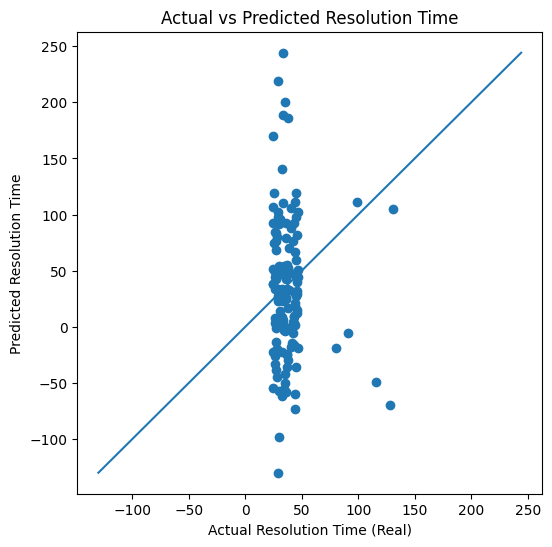

In [ ]:
import matplotlib.pyplot as plt

# Actual values (real output)
y_true = y_test

# Predicted values
y_predicted = y_pred

# Create scatter plot
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_predicted)

# Labels
plt.xlabel("Actual Resolution Time (Real)")
plt.ylabel("Predicted Resolution Time")
plt.title("Actual vs Predicted Resolution Time")

# Perfect prediction line (diagonal reference)
min_val = min(y_true.min(), y_predicted.min())
max_val = max(y_true.max(), y_predicted.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.show()


In [ ]:
#User Input Prediction


print("\n--- Write your complaint ---")
user_input = input("Enter your complaint description: ")


def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

cleaned_input = clean_text(user_input)

# Convert to TF-IDF vector using the same vectorizer
input_vector = vectorizer.transform([cleaned_input])


predicted_time = model.predict(input_vector)[0]

print(f"\nEstimated Resolution Time: {predicted_time:.2f} hours")



--- Write your complaint ---
